In [48]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from astropy.timeseries import LombScargle
from scipy.optimize import minimize_scalar, brentq
import toolz as tz

In [49]:
df1 = pd.read_csv("star1.csv", sep=r"\s+", header=None)
df2 = pd.read_csv("star2.csv", sep=r"\s+", header=None)
df3 = pd.read_csv("star3.csv", sep=r"\s+", header=None)
df4 = pd.read_csv("star4.csv", sep=r"\s+", header=None)
df5 = pd.read_csv("star5.csv", sep=r"\s+", header=None)

In [50]:
tiempo1 = df1[0] 
tiempo2 = df2[0] 
tiempo3 = df3[0] 
tiempo4 = df4[0] 
tiempo5 = df5[0] 

magnitud1 = df1[1]
magnitud2 = df2[1]
magnitud3 = df3[1]
magnitud4 = df4[1]
magnitud5 = df5[1]

In [51]:
estrellas = [{"t": tiempo1, "mag": magnitud1},{"t": tiempo2, "mag": magnitud2},
    {"t": tiempo3, "mag": magnitud3},{"t": tiempo4, "mag": magnitud4},{"t": tiempo5, "mag": magnitud5},]

In [52]:
def limpiar(t, mag):
    mask = (np.isfinite(t) & np.isfinite(mag))
    t = np.array(t)[mask]
    mag = np.array(mag)[mask]
    idx = np.argsort(t)
    return t[idx], mag[idx]

In [53]:
def buscar_periodo(t, mag, pmin=100, pmax=1000):
    """Retorna freq, power, P — como siempre."""
    freq, power = LombScargle(t, mag).autopower(
        minimum_frequency=1/pmax,
        maximum_frequency=1/pmin,
        samples_per_peak=20)
    P = float(1/freq[np.argmax(power)])
    return freq, power, P

def get_periodo(t, mag, pmin=100, pmax=1000):
    """Retorna solo el período como float — para usar en el pipeline."""
    _, _, P = buscar_periodo(t, mag, pmin, pmax)
    return P

In [54]:
def calcular_fase(t,mag,P):
    t0 = t[np.argmin(mag)]
    return ((t-t0)/P)%1

In [55]:
def refinar_periodo(t,mag,P0,frac=0.1,N=300):
    P0 = float(P0) 
    periodos = np.linspace(P0*(1-frac),P0*(1+frac),N)
    dispersion=[]
    for P in periodos:
        fase=((t-t.min())/P)%1
        bins=np.linspace(0,1,30)
        sig=[]
        for i in range(len(bins)-1):
            m=((fase>=bins[i]) & (fase<bins[i+1]))
            if np.sum(m)>5:
                sig.append(np.std(mag[m]))
        dispersion.append(np.mean(sig))
    return float(periodos[np.argmin(dispersion)])

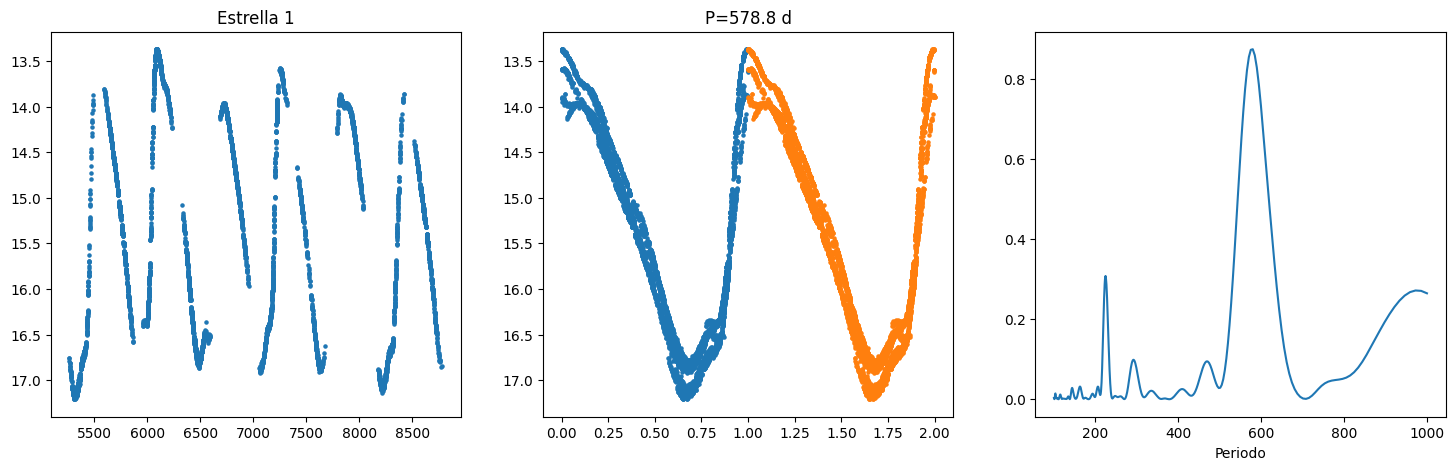

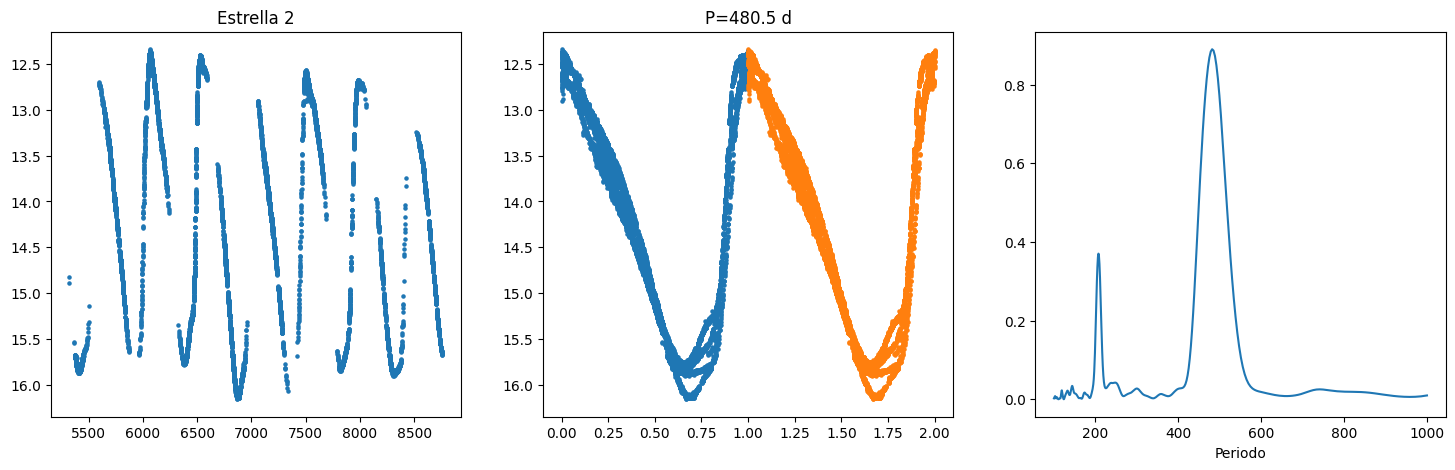

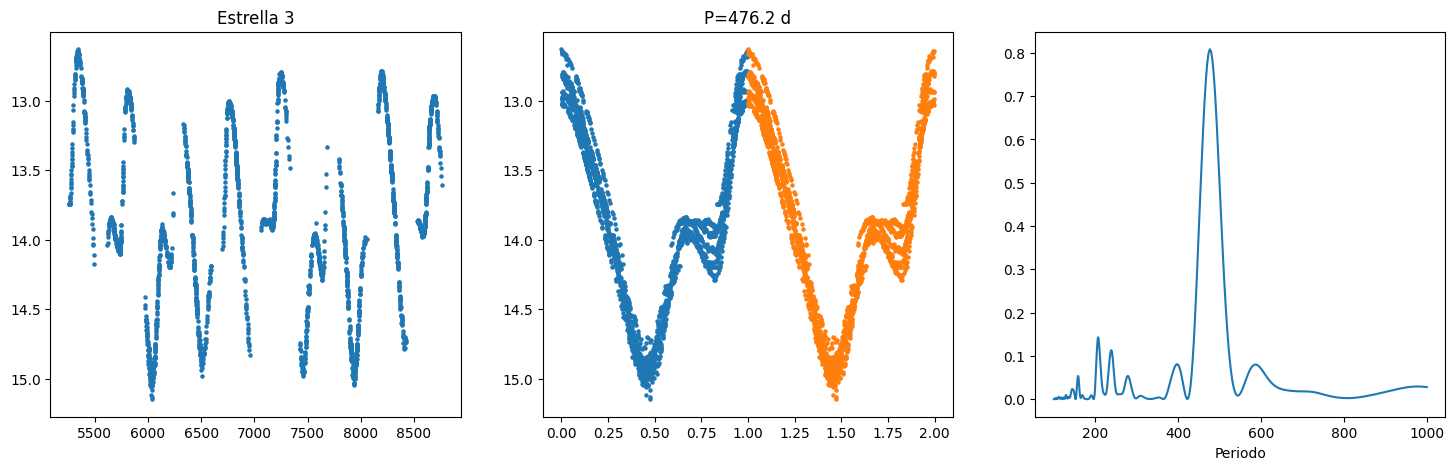

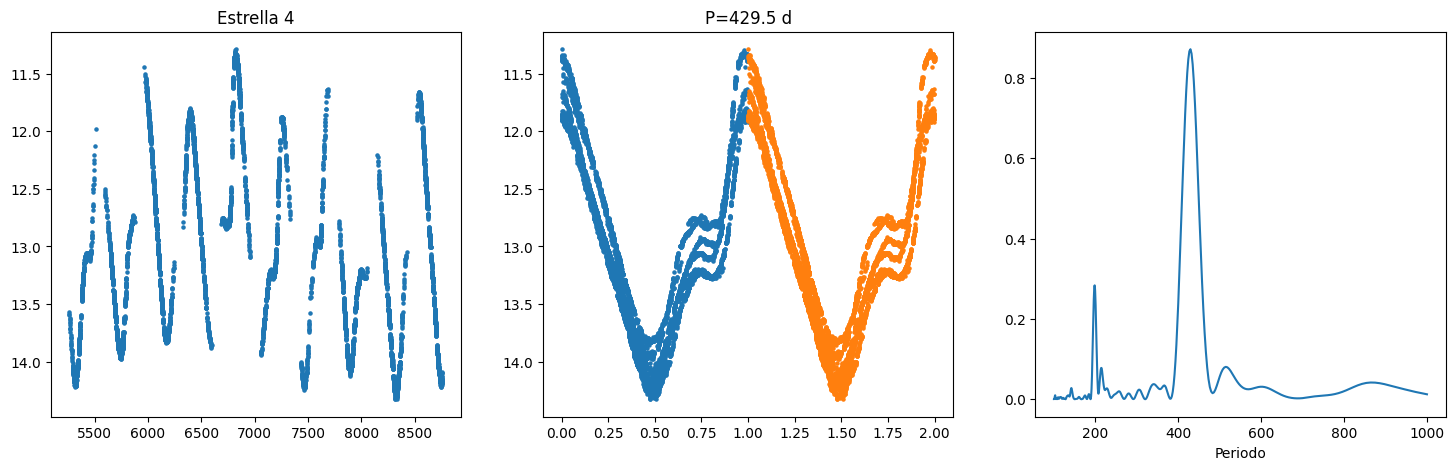

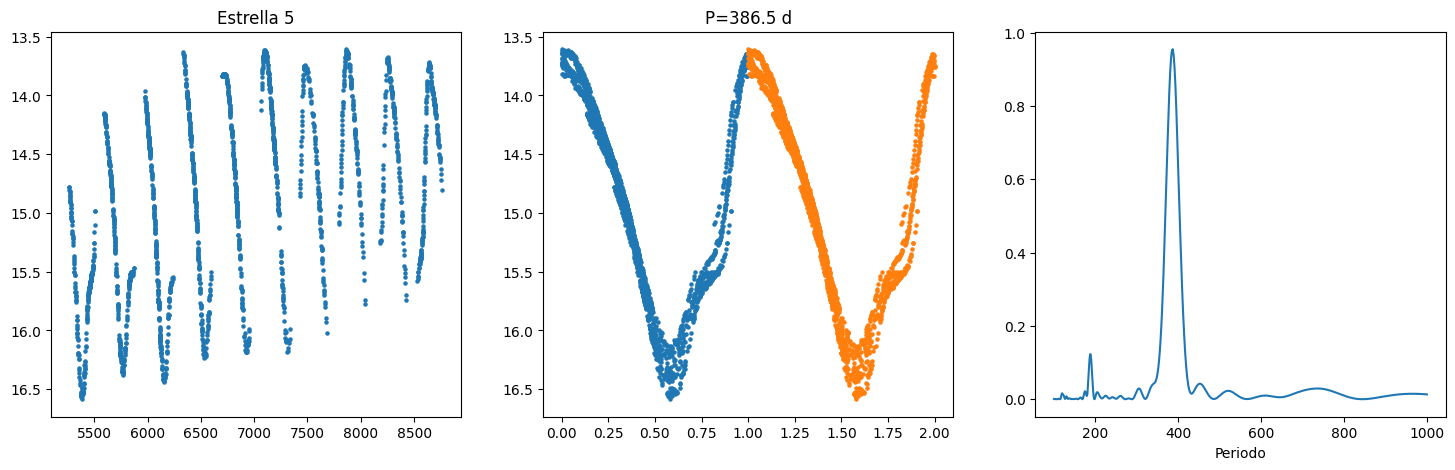

In [56]:
resultados=[]

for i, estrella in enumerate(estrellas):
    t, mag = limpiar(estrella["t"],estrella["mag"])
    freq, power, P0 = buscar_periodo(t,mag)
    P = refinar_periodo(t,mag,P0)
    fase = calcular_fase(t,mag,P)

    resultados.append({"estrella":i+1,"P_LS":P0,"P_final":P})
    order=np.argsort(fase)
    
    fig,ax=plt.subplots(1,3,figsize=(18,5))

    ax[0].scatter(t,mag,s=5)
    ax[0].invert_yaxis()
    ax[0].set_title(f"Estrella {i+1}")


    ax[1].scatter(fase[order],mag[order],s=5)
    ax[1].scatter(fase[order]+1,mag[order],s=5)
    ax[1].invert_yaxis()
    ax[1].set_title(f"P={P:.1f} d")


    ax[2].plot(1/freq,power)
    ax[2].set_xlabel("Periodo")
    plt.show()

In [57]:
pd.DataFrame(resultados)

,estrella,P_LS,P_final
0,1,579.741972,578.772503
1,2,481.641669,480.514080
2,3,476.381462,476.222137
3,4,429.357558,429.501156
4,5,386.584015,386.454723


In [58]:
ciclo=np.floor((t-t.min())/P).astype(int)

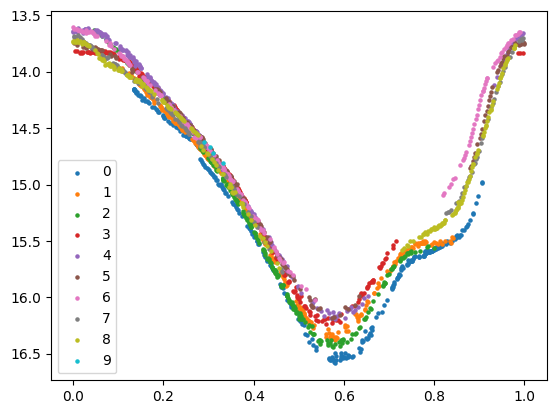

In [59]:
for c in np.unique(ciclo):
    m=ciclo==c
    plt.scatter(fase[m],mag[m],s=5,label=c)
plt.gca().invert_yaxis()
plt.legend()

El periodo que encontramos parece estar bien para cada estrella. También revisamos que la forma rara se da por un cambio entre los ciclos, no por cosas más extrañas. entonces, ahora vamos a empezar a utilizar fourier para refinar estos resultados, pero no necesariamente el periodo.

In [60]:
class FourierSeries:
    def __init__(self,n_terms=None,base_freq=None,custom_freqs=None):
        """Represents the b0 + Σₙ [ Aₙ cos(2πfₙt) + Bₙ sin(2πfₙt) ] series. 
        If initialized with only `n_terms`, the `base_freq` is assumed to be 1.0. 
        fₙ = n*base_freq, unless `custom_freqs` is provided, which is used to extract the fₙ.
        If both `custom_freqs` and `n_terms` are specified, the first n elements are used.
        If none are specified, the series will have one term by default.
        """
        self.fitted = False

        if custom_freqs is not None:
            if n_terms is None:
                n_terms = len(custom_freqs)
            self._freqs = np.array(custom_freqs[:n_terms])
        else:
            if n_terms is None:
                n_terms = 1
            if base_freq is None:
                base_freq = 1.0
            self._freqs = np.array([(i+1)*base_freq for i in range(n_terms)])
        self.n_terms = n_terms
        self._raw_coef = np.zeros(1+2*n_terms)
        self._param_names = ["base"] + list(tz.interleave((
            [f"A_{i+1}" for i in range(n_terms)],
            [f"B_{i+1}" for i in range(n_terms)]
        )))
    
    def __repr__(self):
        return f"<FourierSeries with {self.n_terms} terms>\nfitted: {self.fitted}\nparameters:\n" + self.parameters.to_string()
    
    def _design_matrix(self,ts):
        ts = np.array(ts)
        N = len(ts)
        const = np.ones(N)
        SIN = np.sin(2*np.pi*self._freqs[:,None]*ts[None,:])
        COS = np.cos(2*np.pi*self._freqs[:,None]*ts[None,:])
        return np.vstack([const] + list(tz.interleave([SIN,COS]))).T
        
    def __call__(self,t):
        scalar = np.isscalar(t)
        T = np.atleast_1d(t)
        X = self._design_matrix(T)
        return X @ self._raw_coef
    
    @property
    def parameters(self):
        return pd.Series(self._raw_coef,index=self._param_names)

    @property
    def A_n(self):
        return self._raw_coef[1::2]

    @property
    def B_n(self):
        return self._raw_coef[2::2]
        
        
    def fit(self,xdata,ydata,weights=None):
        """Performs OLS fit on the given data, which must be free of NaNs and infinite values.
        This instance is given the fitted parameters and the covariance matrix
        """
        X = self._design_matrix(xdata)
        self._raw_coef = np.linalg.pinv(X) @ ydata
        response = X @ self._raw_coef
        self.fitted = True
        return ydata - response

In [61]:
def amplitudes(self):
    # Los coeficientes van: base, A1, B1, A2, B2, ...
    An = self._raw_coef[1::2]  # índices 1, 3, 5, 7
    Bn = self._raw_coef[2::2]  # índices 2, 4, 6, 8
    return np.sqrt(An**2 + Bn**2)

def phases(self):
    An = self._raw_coef[1::2]
    Bn = self._raw_coef[2::2]
    return np.arctan2(Bn, An)

FourierSeries.amplitudes = property(amplitudes)
FourierSeries.phases     = property(phases)

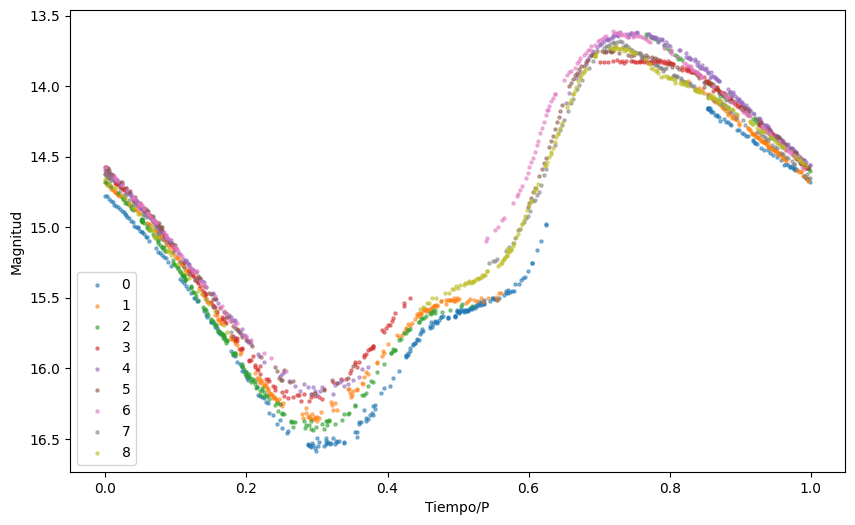

In [62]:
plt.figure(figsize=(10,6))

for c in np.unique(ciclo):
    m = ciclo==c
    if np.sum(m)<30:
        continue
    tc = t[m]
    yc = mag[m]
    fase_local=((tc-tc.min())/P)
    plt.scatter(fase_local,yc,s=5,alpha=0.5,label=f"{c}")

plt.gca().invert_yaxis()
plt.xlabel("Tiempo/P")
plt.ylabel("Magnitud")
plt.legend()
plt.show()

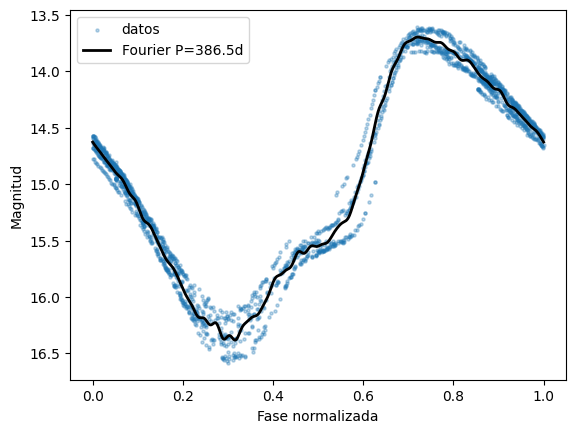

base    15.017959
A_1      1.132804
B_1     -0.431687
A_2     -0.064244
B_2      0.070045
          ...    
B_38     0.003484
A_39     0.004173
B_39    -0.000120
A_40    -0.002453
B_40    -0.001659
Length: 81, dtype: float64


In [63]:
# Un solo modelo ajustado sobre todos los datos plegados juntos
fase_global = ((t - t.min()) / P) % 1
order = np.argsort(fase_global)
fase_ord = fase_global[order]
mag_ord = mag[order]  # mag también debe ser array ordenado

fs_global = FourierSeries(n_terms=40, base_freq=1)
res = fs_global.fit(fase_ord, mag_ord)

ff = np.linspace(0, 1, 1000)
plt.scatter(fase_ord, mag_ord, s=5, alpha=0.3, label="datos")
plt.plot(ff, fs_global(ff), lw=2, color='black', label=f"Fourier P={P:.1f}d")
plt.gca().invert_yaxis()
plt.xlabel("Fase normalizada")
plt.ylabel("Magnitud")
plt.legend()
plt.show()
print(fs_global.parameters)

Confirmamos que se trata de una mira con esta parábola, lo observado y lo calculado se empuezan a desviar a medida que pasan los ciclos.

In [64]:
def OC_por_ciclo(t, mag, ciclo, P):
    ns, ocs = [], []
    
    # t0 = tiempo del máximo de magnitud (mínimo brillo) en ciclo 0
    m0 = ciclo == np.min(ciclo[ciclo >= 0])  
    if m0.sum() >= 5:
        t0 = t[m0][np.argmax(mag[m0])]
    else:
        t0 = t[np.argmax(mag)]  # fallback
    
    for c in np.unique(ciclo):
        m = ciclo == c
        if m.sum() < 30:
            continue
        tc, yc = t[m], mag[m]
        t_obs  = tc[np.argmax(yc)]
        t_calc = t0 + c * P
        ns.append(c)
        ocs.append(t_obs - t_calc)

    # Para estrella 5, después de calcular ns, ocs:
    coeffs = np.polyfit(ns, ocs, 1)   # ajuste lineal
    pendiente = coeffs[0]              # días por ciclo

    P_corregido = P + pendiente        # corrección directa
    print(f"Pendiente O-C: {pendiente:.2f} d/ciclo")
    print(f"P corregido:   {P_corregido:.2f} d")
    return np.array(ns), np.array(ocs)

In [65]:
def delta_fase_por_ciclo(fase_global, mag, ciclo, fs_global):
    """Desplazamiento Δφ que minimiza residuo de cada ciclo vs modelo global."""
    deltas = {}
    for c in np.unique(ciclo):
        m = ciclo == c
        if m.sum() < 30:
            continue
        fc, yc = fase_global[m], mag[m]
        def res(d):
            return np.sum((yc - fs_global((fc + d) % 1))**2)
        r = minimize_scalar(res, bounds=(-0.3, 0.3), method='bounded')
        deltas[c] = r.x
    return deltas

In [66]:
archivos = ["star1.csv","star2.csv","star3.csv","star4.csv","star5.csv"]
estrellas_raw = [pd.read_csv(f, sep=r"\s+", header=None) for f in archivos]

Pendiente O-C: 1.54 d/ciclo
P corregido:   580.31 d
Pendiente O-C: -4.81 d/ciclo
P corregido:   475.71 d
Pendiente O-C: -20.49 d/ciclo
P corregido:   455.73 d
Pendiente O-C: 0.24 d/ciclo
P corregido:   429.74 d
Pendiente O-C: -5.88 d/ciclo
P corregido:   380.57 d


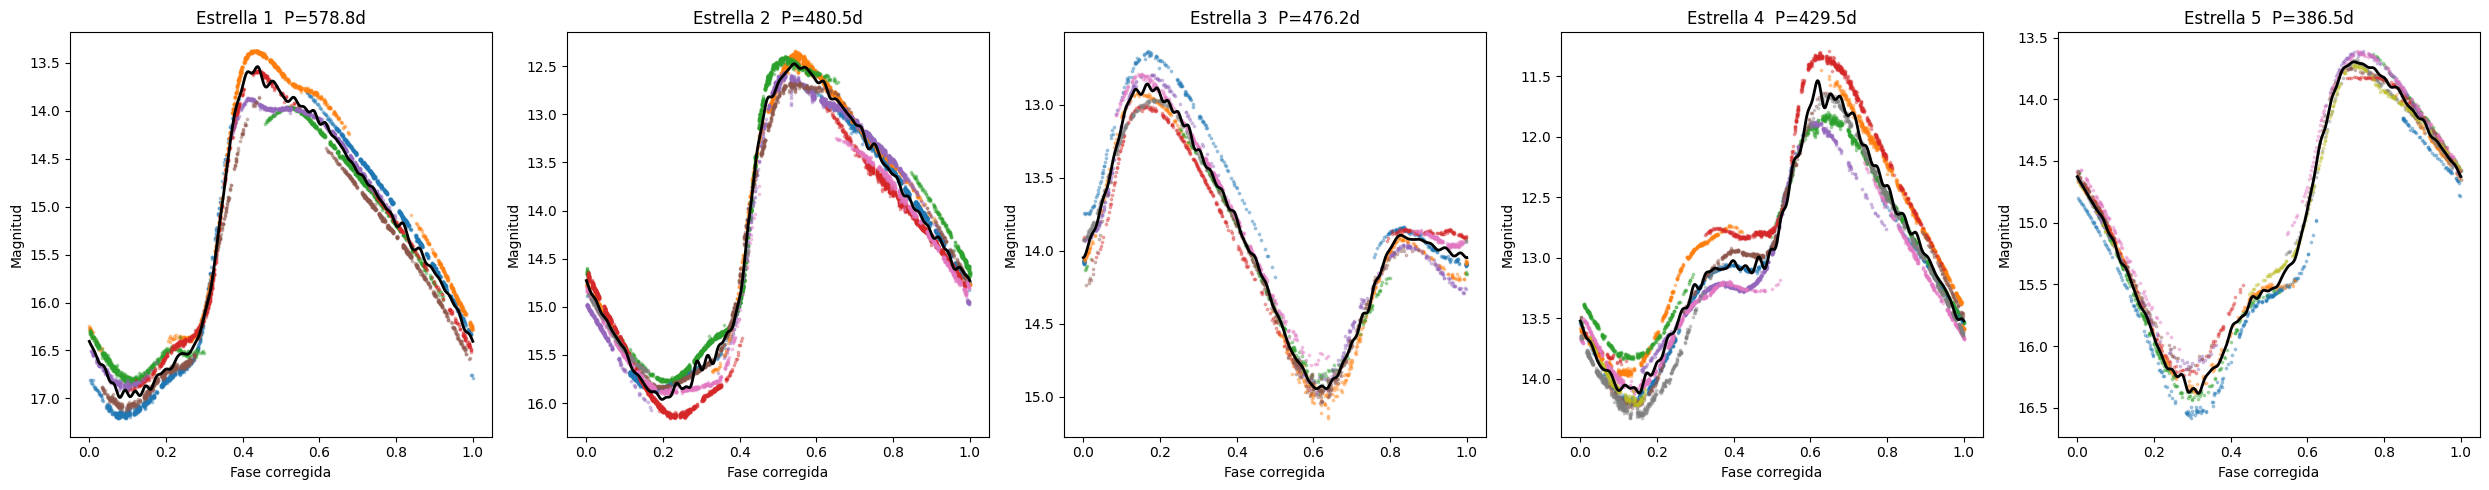

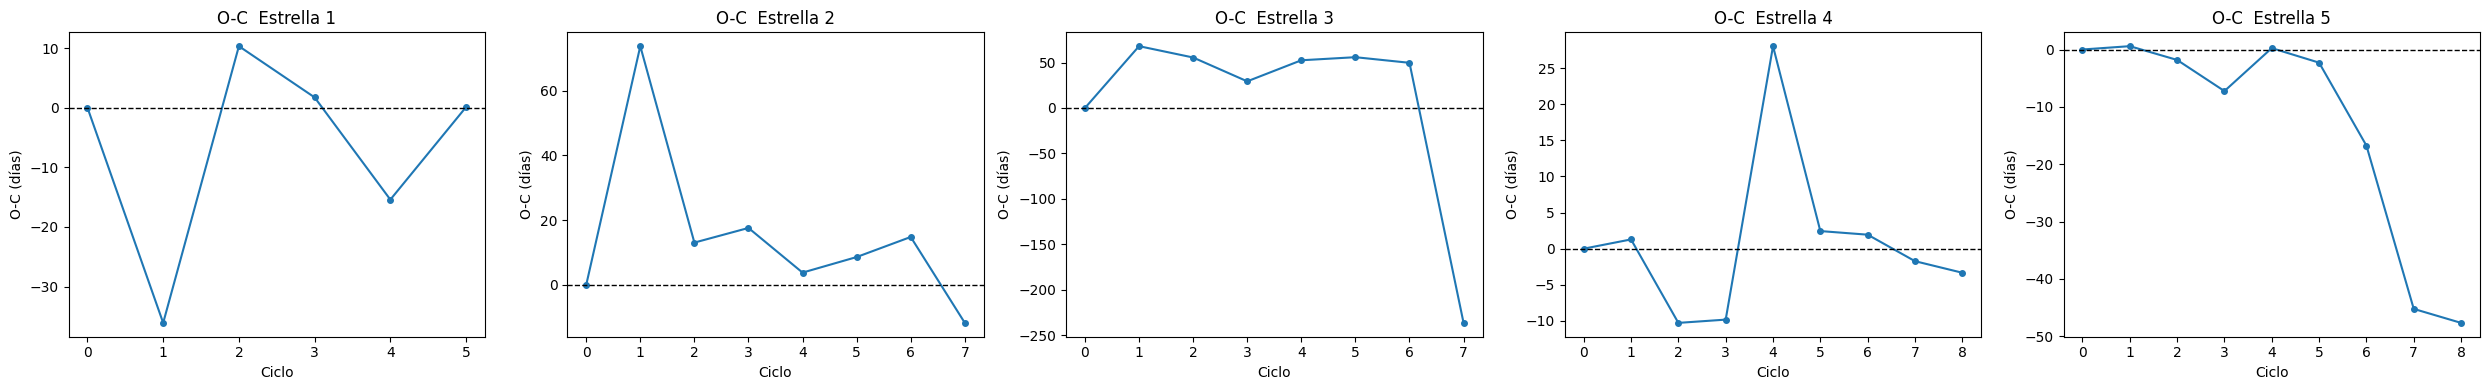

In [67]:
resultados = []

fig_fold, axes_fold = plt.subplots(1, 5, figsize=(25, 5))
fig_oc,   axes_oc   = plt.subplots(1, 5, figsize=(25, 4))

for i, df in enumerate(estrellas_raw):
    t, mag = limpiar(df[0], df[1])
    # 1. Período
    P0 = get_periodo(t, mag)
    P  = refinar_periodo(t, mag, P0)
    # 2. Fase global
    ciclo        = np.floor((t - t.min()) / P).astype(int)
    fase_global  = ((t - t.min()) / P) % 1
    order        = np.argsort(fase_global)
    fase_ord     = fase_global[order]
    mag_ord      = mag[order]
    # 3. Fourier global
    fs = FourierSeries(n_terms=40, base_freq=1.0)
    res = fs.fit(fase_ord, mag_ord)
    rms = np.std(res)
    # 4. O-C
    ns, ocs = OC_por_ciclo(t, mag, ciclo, P)
    # Después de calcular ns, ocs:
    if len(ns) >= 4:
        pendiente = np.polyfit(ns, ocs, 1)[0]
        P_oc = P + pendiente  # período corregido por O-C
    else:
        P_oc = P
    # 5. Δφ por ciclo
    deltas       = delta_fase_por_ciclo(fase_global, mag, ciclo, fs)
    # 6. Parámetros de Fourier
    A = fs.amplitudes          # A1, A2, A3, A4
    phi = fs.phases
    R21  = A[1]/A[0]
    phi21 = phi[1] - 2*phi[0]
    resultados.append({"estrella":i+1,"P_LS":round(P0, 2),"P_final":round(P,  2),
        "P_OC":round(P_oc, 2),"OC_pendiente":round(pendiente, 3),"A1":round(A[0], 4),
        "R21":round(R21,  4),"phi21":round(phi21, 4),"RMS":round(rms,  4),"OC_std":round(np.std(ocs), 2),})
    # ── gráfica curva plegada corregida ───────────────────────────────────────
    ax = axes_fold[i]
    for c in np.unique(ciclo):
        m = ciclo == c
        if m.sum() < 30 or c not in deltas:
            continue
        fase_c = (fase_global[m] + deltas[c]) % 1
        ax.scatter(fase_c, mag[m], s=3, alpha=0.35)

    ff = np.linspace(0, 1, 1000)
    ax.plot(ff, fs(ff), lw=2, color='black')
    ax.invert_yaxis()
    ax.set_title(f"Estrella {i+1}  P={P:.1f}d")
    ax.set_xlabel("Fase corregida")
    ax.set_ylabel("Magnitud")

    # ── gráfica O-C ───────────────────────────────────────────────────────────
    ax2 = axes_oc[i]
    ax2.plot(ns, ocs, 'o-', ms=4)
    ax2.axhline(0, color='k', lw=1, ls='--')
    ax2.set_title(f"O-C  Estrella {i+1}")
    ax2.set_xlabel("Ciclo")
    ax2.set_ylabel("O-C (días)")

fig_fold.tight_layout();  fig_fold.savefig("curvas_plegadas.png", dpi=150)
fig_oc.tight_layout();    fig_oc.savefig("OC_diagrams.png",      dpi=150)
plt.show()

In [68]:
tabla = pd.DataFrame(resultados)
print(tabla.to_string(index=False))

 estrella   P_LS  P_final   P_OC  OC_pendiente     A1    R21   phi21    RMS  OC_std
        1 579.74   578.77 580.31         1.540 1.5292 0.2989 -3.0285 0.1543   15.23
        2 481.64   480.51 475.71        -4.806 1.5728 0.2998 -3.1301 0.1362   23.89
        3 476.38   476.22 455.73       -20.488 0.7967 0.3342  6.4242 0.0991   94.88
        4 429.36   429.50 429.74         0.239 0.9984 0.1927  0.5878 0.1692   10.57
        5 386.58   386.45 380.57        -5.882 1.2123 0.0784  3.0412 0.0949   18.42


In [73]:
import os
import numpy as np
import pandas as pd


def limpiar_df(df):

    t = pd.to_numeric(df.iloc[:,0], errors="coerce")
    y = pd.to_numeric(df.iloc[:,1], errors="coerce")

    mask = np.isfinite(t) & np.isfinite(y)

    out = pd.DataFrame({
        "t": t[mask],
        "y": y[mask]
    })

    return out.sort_values("t").reset_index(drop=True)


def fraccion_coincidente(df_star, df_ref, tol=1e-4):

    A = limpiar_df(df_star)
    B = limpiar_df(df_ref)

    tA = A["t"].values
    tB = B["t"].values

    matches = 0

    for t in tA:
        if np.any(np.abs(tB - t) < tol):
            matches += 1

    return matches / len(tA)


stars = {}

for i in range(1,6):
    stars[f"star{i}.csv"] = pd.read_csv(
        f"star{i}.csv",
        sep=r"\s+",
        header=None
    )

carpeta = "data_selected"

for nombre, star in stars.items():

    mejor = None
    score = 0

    for archivo in os.listdir(carpeta):

        if not archivo.endswith(".csv"):
            continue

        try:

            ref = pd.read_csv(
                os.path.join(carpeta, archivo)
            )

            s = fraccion_coincidente(star, ref)

            if s > score:
                score = s
                mejor = archivo

        except:
            pass

    print(f"\n{nombre}")
    print("mejor match:", mejor)
    print("fracción:", round(score,3))


star1.csv
mejor match: None
fracción: 0

star2.csv
mejor match: OGLE-BLG-LPV-124320.csv
fracción: 0.537

star3.csv
mejor match: None
fracción: 0

star4.csv
mejor match: None
fracción: 0

star5.csv
mejor match: None
fracción: 0


Por alguna razón las estrellas no están en los archivos descargados, pero yo tengo los nombres y sé que las estrellas existen